In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder

!wget https://raw.githubusercontent.com/monkIIlol/Repo-Programacion/refs/heads/main/data/dataset_clientes.csv
data = pd.read_csv("dataset_clientes.csv")

--2026-04-09 03:40:18--  https://raw.githubusercontent.com/monkIIlol/Repo-Programacion/refs/heads/main/data/dataset_clientes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3282843 (3.1M) [text/plain]
Saving to: ‘dataset_clientes.csv.3’

dataset_clientes.cs 100%[===================>]   3.13M  --.-KB/s    in 0.03s   

2026-04-09 03:40:18 (98.2 MB/s) - ‘dataset_clientes.csv.3’ saved [3282843/3282843]



# **ANÁLISIS EDA**

### Lo primero que queremos es una vista general del contenido del DF:

In [122]:
data

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,4925,2021-08-09,47,Femenino,Centro,Divorciado,4.818457e+05,523321.283921,1.750852e+06,715.276140,...,39,Alto,Basico,1,0,Web,Viernes,4,5831,0
20396,1627,2021-10-26,18,Masculino,Sur,Divorciado,1.062000e+06,692112.449676,1.865442e+06,662.855074,...,319,Bajo,Premium,3,0,Web,Domingo,17,2925,0
20397,13007,2022-10-05,76,Femenino,Norte,Soltero,1.595617e+06,568544.699045,1.862204e+06,640.595219,...,325,Medio,Estandar,4,0,App,Viernes,16,1660,0
20398,17724,2020-01-10,23,Otro,Sur,Casado,8.056724e+05,348930.779211,2.032151e+06,466.372014,...,81,Bajo,Premium,2,0,Tienda,Lunes,14,4561,1


De esto sacamos que el dataset contiene 20.400 registros y 22 columnas.

## Calidad de los datos (errores duros)

(En esta sub-etapa, necesitamos conocer nulos, duplicados e inconsistencias)

### Necesitamos una vista estructural que nos permita conocer los tipos de datos y saber si hay nulos:

In [123]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             20400 non-null  int64  
 1   fecha_registro         20400 non-null  object 
 2   edad                   20400 non-null  int64  
 3   genero                 20400 non-null  object 
 4   region                 20400 non-null  object 
 5   estado_civil           20400 non-null  object 
 6   ingreso_mensual        19379 non-null  float64
 7   gasto_mensual          19375 non-null  float64
 8   deuda_total            20400 non-null  float64
 9   score_crediticio       19379 non-null  float64
 10  antiguedad_meses       20400 non-null  int64  
 11  frecuencia_compra      20400 non-null  int64  
 12  ultima_compra_dias     20400 non-null  int64  
 13  uso_app                20400 non-null  object 
 14  tipo_plan              20400 non-null  object 
 15  nu



Se observan distintos tipos de datos, incluyendo variables numéricas (enteras y decimales) y categóricas (tipo object).

Las variables numéricas corresponden a información cuantitativa como edad, ingresos y gasto, mientras que las variables categóricas representan características como género, región y tipo de plan.

Además, se identifican valores nulos en algunas variables, lo que indica la necesidad de realizar un proceso de limpieza de datos.

### Buscamos Nulos

Necesitamos saber cuantos nulos hay por columna

In [124]:
data.isnull().sum()

,0
id_cliente,0
fecha_registro,0
edad,0
genero,0
region,0
estado_civil,0
ingreso_mensual,1021
gasto_mensual,1025
deuda_total,0
score_crediticio,1021


#### Por cada columna que tenga valores **NaN** (ingreso_mensual, gasto_mensual, score_crediticio) vamos a calcular el porcentaje de nulos:

#### ingreso_mensual

In [125]:
print(f"porcentaje de nulos en ingreso_mensual: {data['ingreso_mensual'].isnull().sum().sum() / data['ingreso_mensual'].size * 100:.4f}%")

porcentaje de nulos en ingreso_mensual: 5.0049%


#### gasto_mensual

In [126]:
print(f"porcentaje de nulos en gasto_mensual: {data['gasto_mensual'].isnull().sum().sum() / data['gasto_mensual'].size * 100:.4f}%")

porcentaje de nulos en gasto_mensual: 5.0245%


#### score_crediticio

In [127]:
print(f"porcentaje de nulos en score_crediticio: {data['score_crediticio'].isnull().sum().sum() / data['score_crediticio'].size * 100:.4f}%")

porcentaje de nulos en score_crediticio: 5.0049%


#### Ahora solo para tener una idea más general del total de nulos, sacaremos el porcentaje de nulos total del DF.

In [128]:
print(f"porcentaje nulos en total: {data.isnull().sum().sum() / data.size * 100:.4f}%")

porcentaje nulos en total: 0.6834%


Se identifican valores nulos en las variables ingreso mensual, gasto mensual, y score crediticio. Estos valores faltantes representan aproximadamente un 5% del total de datos de su columna correspondiente, por lo que se evaluará su tratamiento mediante imputación en lugar de eliminar registros, con el fin de no perder información relevante

### Buscamos Duplicados

Se eliminan registros duplicados para evitar sesgos en el análisis, ya que un mismo cliente repetido puede distorsionar métricas clave como la tasa de abandono y afectar la representatividad de los resultados.

In [129]:
data.duplicated().sum()

np.int64(400)

Se identificaron 400 registros duplicados en el dataset, lo que corresponde aproximadamente al 2% del total de datos.

Aunque el porcentaje no es elevado, la presencia de duplicados puede generar sesgos en el análisis al sobre representar ciertos registros, por lo que se considera su eliminación en la etapa de limpieza.

## Forma de los datos (análisis estadístico)

(En esta sub-etapa, debemos conocer la distribución de los datos y outliers, y sobre todo, analizar la variable más importante: **abandono**)

### Necesitamos una vista estadística para tener una primera impresión de las Medidas de Tendencia Central, Medidas de Posición y sobre todo, la dispersión de los datos:

In [130]:
data.loc[:, ~data.columns.isin(['id_cliente', 'abandono'])].describe()

,edad,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,tiene_tarjeta_credito,hora_registro,codigo_postal
count,20400.00000,1.937900e+04,19375.000000,2.040000e+04,19379.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000,20400.000000
mean,48.54598,8.330390e+05,399453.495188,2.061953e+06,600.441593,60.205882,9.966765,182.325686,2.994853,0.501373,11.416716,5488.970147
std,17.84971,4.301978e+05,150831.135171,1.055155e+06,100.408685,34.210052,5.460586,105.056827,1.410716,0.500010,6.891420,2602.374998
min,18.00000,-8.302577e+04,-194957.467079,-1.684124e+06,220.516968,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1000.000000
25%,33.00000,6.346396e+05,296753.420113,1.461942e+06,532.872163,31.000000,5.000000,92.000000,2.000000,0.000000,6.000000,3239.000000
50%,48.00000,8.044483e+05,398887.260180,2.017759e+06,600.955064,61.000000,10.000000,181.000000,3.000000,1.000000,11.000000,5477.500000
75%,64.00000,9.737937e+05,500485.426137,2.557871e+06,668.245607,90.000000,15.000000,274.000000,4.000000,1.000000,17.000000,7775.000000
max,79.00000,7.560936e+06,954575.217321,1.777694e+07,998.290682,119.000000,19.000000,364.000000,5.000000,1.000000,23.000000,9998.000000


A partir de las estadísticas descriptivas, se analizan las variables numéricas considerando medidas como la media, mediana y valores extremos.
Se observan diferencias entre la media y la mediana en algunas variables, lo que puede indicar la presencia de valores atípicos (outliers).
Asimismo, se detectan valores negativos en variables financieras como ingreso mensual, gasto mensual y deuda total, lo cual representa una inconsistencia en los datos que deberá ser tratada en la etapa de limpieza.

### Buscamos Outliers

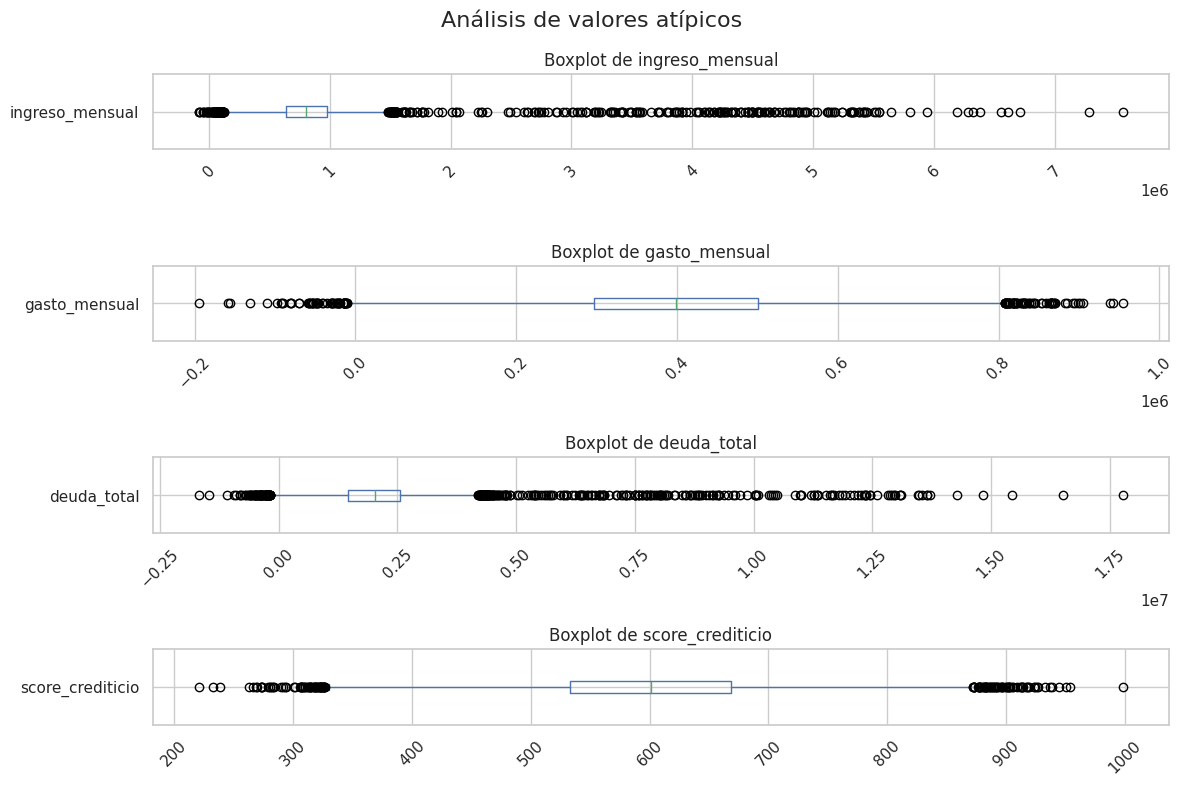

In [131]:
revision_atipicos = [
    'ingreso_mensual',
    'gasto_mensual',
    'deuda_total',
    'score_crediticio'
]


fig, axes = plt.subplots(len(revision_atipicos), 1, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(revision_atipicos):
    data[col].plot(kind='box', ax=axes[i], vert=False)
    axes[i].set_title(f"Boxplot de {col}")
    axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de valores atípicos", fontsize=16)
plt.tight_layout()

plt.show()

A partir de este análisis, se identificaron valores atípicos en las variables financieras analizadas, lo que evidencia la presencia de datos extremos que podrían influir en el análisis y en el rendimiento de modelos predictivos.

Además, se detectaron valores negativos en estas variables, los cuales corresponden a inconsistencias en los datos más que a valores atípicos, ya que no son coherentes con la naturaleza de las variables estudiadas.

### Observamos la distribución de los datos

Se seleccionaron variables numéricas clave relacionadas con el comportamiento financiero y de consumo del cliente, ya que son las que pueden influir directamente en el abandono. Los histogramas permiten analizar su distribución, detectar sesgos y validar la presencia de valores atípicos identificados previamente

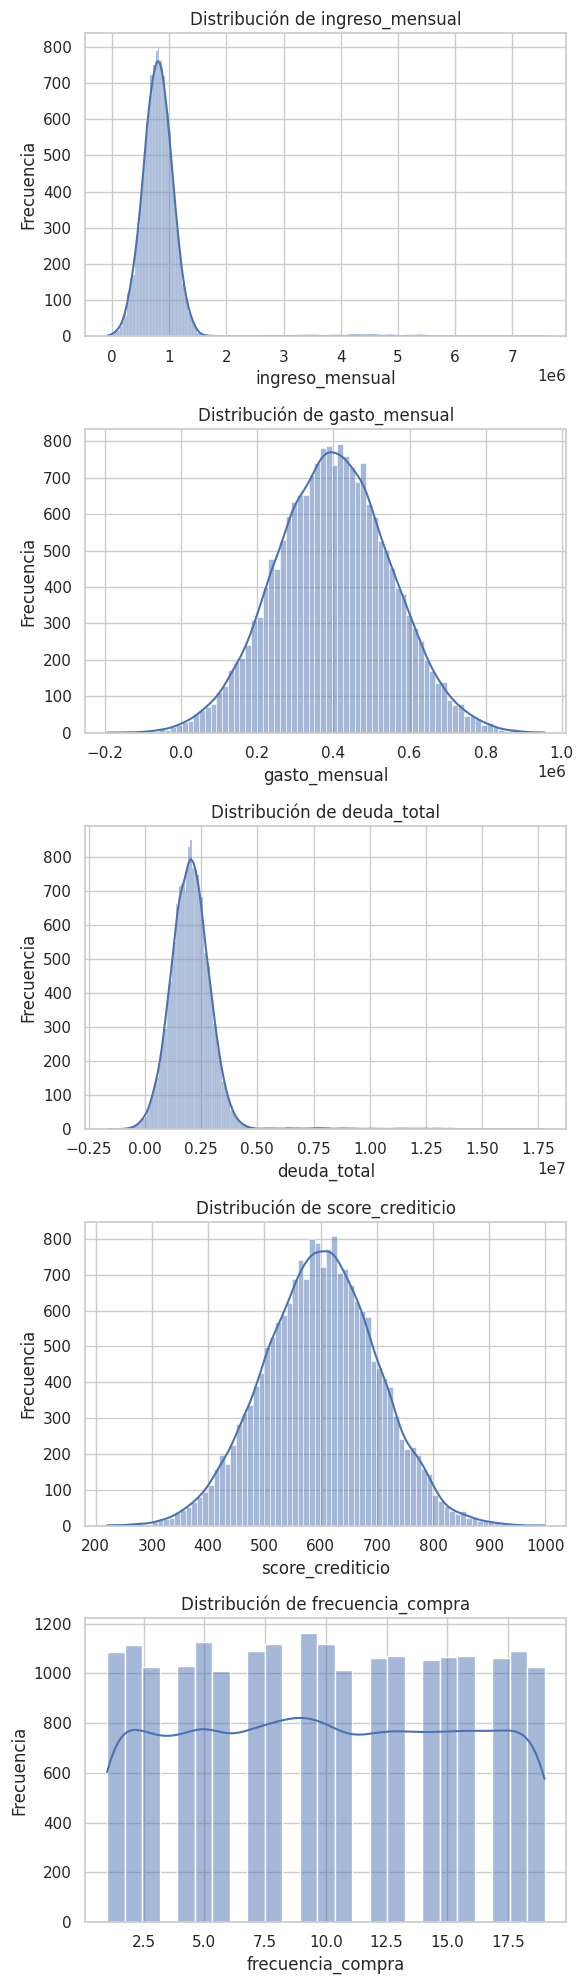

In [132]:
import seaborn as sns

variables = [
    'ingreso_mensual',
    'gasto_mensual',
    'deuda_total',
    'score_crediticio',
    "frecuencia_compra"
]

num_columns = len(variables)
fig, axes = plt.subplots(num_columns, 1, figsize=(6, num_columns * 4))
axes = axes.flatten()

for i, col in enumerate(variables):
    sns.histplot(data[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Se identificaron datos inconsistentes en variables financieras, específicamente valores negativos que no son coherentes con la naturaleza de las variables.

### Contamos la cantidad de valores negativos (inconsistencias halladas recien) en cada variable:

In [133]:
cols_a_revisar = ['ingreso_mensual', 'gasto_mensual', 'deuda_total']

for col in cols_a_revisar:
    total_negativos = (data[col] < 0).sum()
    porcentaje = (total_negativos / len(data)) * 100
    print(f"{col}: {total_negativos} valores negativos ({porcentaje:.2f}%)")

ingreso_mensual: 11 valores negativos (0.05%)
gasto_mensual: 68 valores negativos (0.33%)
deuda_total: 143 valores negativos (0.70%)


### Correlación con la variable target: abandono

Se analiza la distribución de la variable objetivo “abandono” para comprender si existe un desbalance, lo cual puede influir en el análisis posterior y en la construcción de modelos:

In [134]:
data['abandono'].value_counts(normalize=True) * 100

,proportion
abandono,
0,60.318627
1,39.681373


A primera vista, vemos un desbalance:

- 60% para 0,
- 40% para 1

La variable objetivo presenta una distribución de aproximadamente 60% de clientes que permanecen y 40% que abandonan. Esto indica un nivel relevante de cancelación del servicio, lo que justifica el análisis de las variables que podrían explicar este comportamiento.

Se comparan las medias y medianas (segun correspondan en base a la distribución que hicimos anteriormente a estas variables) de variables numéricas según el estado de abandono, con el fin de identificar diferencias en el comportamiento financiero y de consumo entre los clientes que abandonan y los que permanecen.

Para:


*   gasto_mensual
*   score_crediticio
*   frecuencia_compra

la **media** es representativa, ya que presentan una distribución simétrica




In [135]:
data.groupby("abandono")[[
    "gasto_mensual",
    "score_crediticio",
    "frecuencia_compra"
]].mean()

,gasto_mensual,score_crediticio,frecuencia_compra
abandono,,,
0,400481.607762,602.786962,10.163104
1,397885.871364,596.881946,9.668314


Se observa que los clientes que abandonan presentan un menor gasto mensual, menor score crediticio y menor frecuencia de compra.
Aunque las diferencias no son grandes, se identifica un patrón consistente de menor actividad y peor perfil financiero en los clientes que abandonan.

Para:


*   ingreso_mensual
    
*   deuda_total

la **mediana** es representativa, ya que ingreso_mensual está sesgada hacia la derecha, tiene una cola larga(outliers), lo mismo con deuda_total.



In [136]:
data.groupby("abandono")[[
    "ingreso_mensual",
    "deuda_total",

]].median()

,ingreso_mensual,deuda_total
abandono,,
0,801627.436140,1.992320e+06
1,807804.664315,2.046122e+06


Se observa que los clientes que abandonan presentan una mayor deuda total, lo que sugiere una posible relación entre carga financiera y abandono.
En cambio, el ingreso mensual no muestra diferencias relevantes, por lo que no sería un factor determinante.

Se analiza la relación entre el tipo de plan, uso de la app y el abandono mediante una tabla de contingencia, con el objetivo de identificar si ciertos planes presentan mayor proporción de cancelación:

In [137]:
pd.crosstab(data["tipo_plan"], data["abandono"], normalize="index") * 100

abandono,0,1
tipo_plan,,
Basico,53.783784,46.216216
Estandar,63.230590,36.769410
Premium,63.742349,36.257651


A partir del análisis del tipo de plan, se observa que los clientes con plan básico presentan una mayor proporción de abandono en comparación con los planes estándar y premium. Esto sugiere que los planes de menor valor podrían estar asociados a una menor fidelización, ya sea por menor percepción de beneficio o menor compromiso con el servicio.

In [138]:
pd.crosstab(data["uso_app"], data["abandono"], normalize="index") * 100

abandono,0,1
uso_app,,
Alto,66.784296,33.215704
Bajo,47.400523,52.599477
Medio,67.019216,32.980784


En relación con el uso de la aplicación, se observa una diferencia significativa en el comportamiento de los clientes. Aquellos con un bajo nivel de uso presentan una mayor proporción de abandono, superando incluso a los clientes que permanecen en el servicio. En contraste, los clientes con uso medio y alto muestran una menor tasa de cancelación. Esto indica que el nivel de interacción con la plataforma es un factor clave en la retención de clientes.

Se analizan las relaciones entre variables numéricas y la variable abandono mediante correlaciones de Pearson y Spearman, con el fin de identificar dependencias lineales y monotónicas que puedan explicar el comportamiento de los clientes:

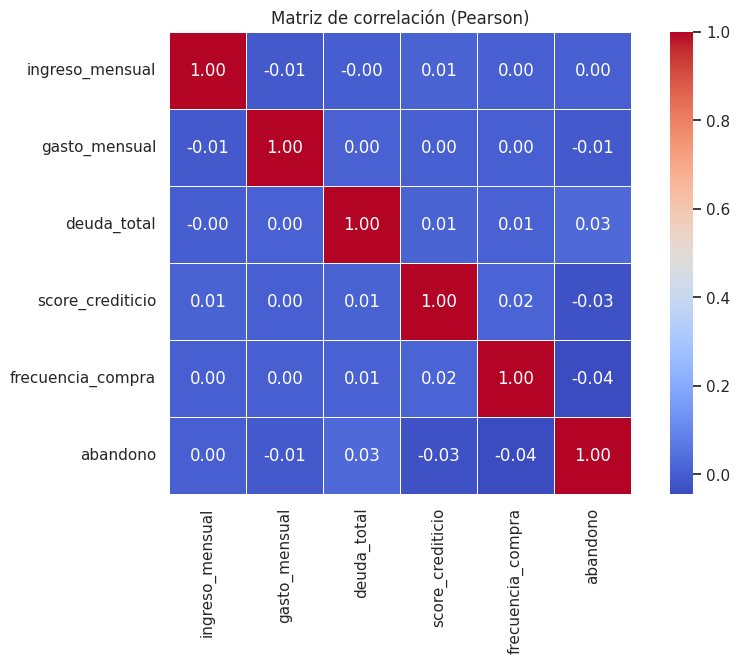

In [139]:
cols_corr = [
    "ingreso_mensual",
    "gasto_mensual",
    "deuda_total",
    "score_crediticio",
    "frecuencia_compra",
    "abandono"
]

corr_pearson = data[cols_corr].corr(method="pearson")

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Matriz de correlación (Pearson)")
plt.show()

La matriz de correlación de Pearson muestra que las variables numéricas presentan valores cercanos a cero en relación con la variable abandono, lo que indica la ausencia de relaciones lineales significativas. Esto sugiere que ninguna variable, por sí sola, explica directamente el abandono de los clientes, reforzando la idea de que se trata de un fenómeno multifactorial.

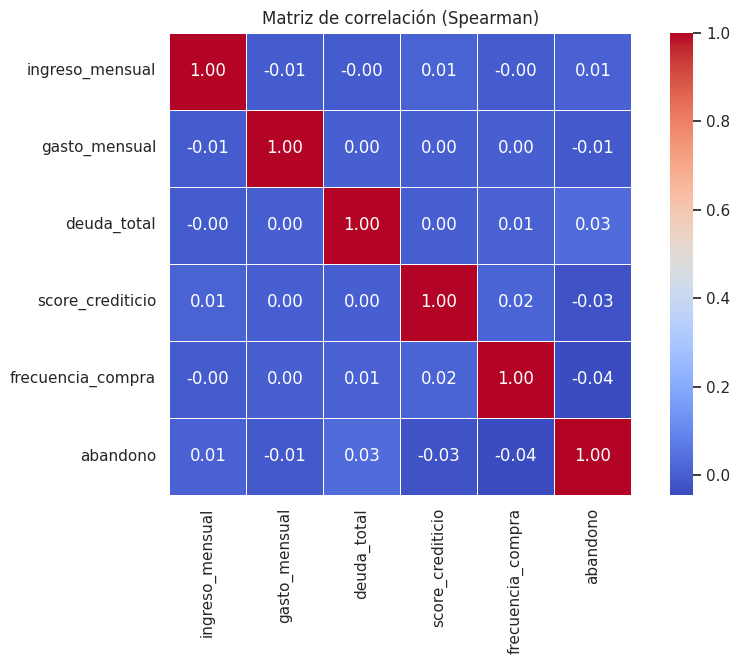

In [140]:
corr_spearman = data[cols_corr].corr(method="spearman")

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Matriz de correlación (Spearman)")
plt.show()

La correlación de Spearman presenta resultados similares a los obtenidos con Pearson, evidenciando también relaciones débiles entre las variables numéricas y el abandono. Esto indica que no existen relaciones monotónicas fuertes, lo que sugiere que el abandono no depende de patrones simples, sino de interacciones más complejas entre variables.

## Cierre del EDA

En síntesis, el análisis exploratorio permitió identificar problemas de calidad en los datos, como nulos, duplicados, inconsistencias y outliers, además de patrones relevantes asociados al abandono. En particular, el uso de la aplicación, la frecuencia de compra, el tipo de plan y algunas variables del perfil financiero muestran señales útiles para comprender la cancelación del servicio. Estos hallazgos fundamentan las decisiones de limpieza y transformación aplicadas en la siguiente etapa.

# **LIMPIEZA**

##Eliminación de duplicados

Se procedio a la eliminación de los registros duplicados para evitar sesgos en el análisis estadístico y garantizar la exactitud de los percentiles

In [141]:
def eliminar_duplicados(X):
  return X.drop_duplicates()


##Tratar inconsistencias

In [142]:
def tratar_inconsistencias(X):
    X = X.copy()

    columnas = ['ingreso_mensual', 'gasto_mensual', 'deuda_total']

    for col in columnas:
        X.loc[X[col] < 0, col] = np.nan

    return X

##Implementación del transformador Winsorizer

Se implementó un Winsorizer para controlar valores extremos mediante percentiles. Se utilizaron límites de 5% y 95% porque permiten reducir el impacto de outliers sin eliminar datos ni afectar significativamente la distribución.

In [143]:
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.05, 0.05)):
        self.limits = limits

    def fit(self, X, y=None):
        # Guardar nombres si es DataFrame para mantener la estructura original
        if isinstance(X, pd.DataFrame):
            self.columns_ = X.columns
        else:
            self.columns_ = [f"col_{i}" for i in range(X.shape[1])]

        return self

    def transform(self, X):
        # Asegurar que trabajamos con un DataFrame y con tipos numéricos precisos
        X = pd.DataFrame(X, columns=self.columns_).copy()
        X = X.astype("float64")

        for col in self.columns_:
            lower = X[col].quantile(self.limits[0])
            upper = X[col].quantile(1 - self.limits[1])
            # np.clip limita los valores al rango [lower, upper]
            X[col] = np.clip(X[col], lower, upper)

        return X

    def get_feature_names_out(self, input_features=None):
        """
        Permite que Scikit-Learn rastree los nombres de las columnas
        después de la transformación.
        """
        if input_features is None:
            return np.array(self.columns_)
        else:
            return np.array(input_features)


##Separación de variables numéricas y categóricas

Se realizó la clasificación de las variables en numéricas y categóricas para aplicar tratamientos de limpieza diferenciados.Dentro de las variables numéricas, se identificaron específicamente aquellas que presentaron valores atípicos.Esta subdivisión permite aplicar técnicas de corrección como la winsorización unicamente en las columnas que lo requieren,evitando acciones innecesarias en el resto de los datos.

In [144]:

#Quitar variable abandono
y = data['abandono']
data = data.drop(columns=['abandono'])

#numericas
data_num = data.select_dtypes(include=['int64', 'float64'])

#categoricas
data_cat = data.select_dtypes(include=['object'])

#columnas con outliers detectados en EDA
outlier_colum = [
    'ingreso_mensual',
    'gasto_mensual',
    'deuda_total',
    'score_crediticio'
]
#numericas sin outliers
sin_outliers = [col for col in data_num.columns if col not in outlier_colum]

##Imputación de variables numéricas sin valores atípicos

Se implementó un Pipeline para organizar las tareas de limpieza en las variables numéricas que no presentaron valores atípicos. Este proceso consistió en la aplicación de un SimpleImputer basado en la mediana, seleccionada por ser robusta que permite completar los valores faltantes sin introducir distorsiones estadísticas en la distribución de los datos.

In [145]:
pipeline_num = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median'))
])

data_num_rest_clean = pipeline_num.fit_transform(data_num[sin_outliers])

data_num_rest_clean = pd.DataFrame(
    data_num_rest_clean,
    columns=sin_outliers,
    index=data.index
)

##Imputacion de variables numéricas con valores atípicos

Se implementó un Pipeline diseñado específicamente para el tratamiento de las variables numéricas que presentaron valores atípicos durante el análisis previo.Este proceso incluyó el uso de un SimpleImputer basado en la mediana para completar los valores faltantes de manera robusta. Adicionalmente, se incorporó una etapa de Winsorización para limitar el impacto de los valores extremos en la distribución de los datos

In [146]:

# Define el pipeline para las variables cuantitativas
pipeline_numerico = Pipeline(
    steps=[
        ("winsorizer", Winsorizer()),
        ("imputacion", SimpleImputer(strategy="mean")),
        ("escalado", StandardScaler())
    ]
)

In [147]:
pipeline_outliers = Pipeline(steps=[
        ('winsor', Winsorizer()),
    ('imputer', SimpleImputer(strategy='mean')),


])

data_outliers_clean = pipeline_outliers.fit_transform(data_num[outlier_colum])

data_outliers_clean = pd.DataFrame(
    data_outliers_clean,
    columns=outlier_colum,
    index=data.index
)

##Imputación de variables categóricas

Se realizó el tratamiento de los valores faltantes en las variables cualitativas del conjunto de datos mediante una estrategia de imputación por moda.Este procedimiento consistió en la aplicación de un SimpleImputer utilizando la técnica most_frequent, la cual permite completar los registros vacíos con la categoría más común de cada columna.

In [148]:
imputer_cat = SimpleImputer(strategy='most_frequent')

data_cat_clean = imputer_cat.fit_transform(data_cat)

data_cat_clean = pd.DataFrame(
    data_cat_clean,
    columns=data_cat.columns,
    index=data.index
)

##Integración final del conjunto de datos procesado

Se realizó la unión de los subconjuntos de datos ya procesados mediante la función pd.concat. Este paso consistió en integrar las variables numéricas sin valores atípicos, las variables con outliers corregidos y las variables categóricas completadas. Con esto,se asegura que el dataset final esté totalmente limpio,y listo para las siguientes etapas del proyecto.

In [149]:
data_clean = pd.concat([
    data_num_rest_clean,
    data_outliers_clean,
    data_cat_clean
], axis=1)

La variable abandono se va a reincorporar al final, una vez finalizado el proceso de limpieza y consolidado el dataset.

In [150]:
data_clean['abandono'] = y

data_clean

,id_cliente,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,tiene_tarjeta_credito,hora_registro,codigo_postal,ingreso_mensual,...,score_crediticio,fecha_registro,genero,region,estado_civil,uso_app,tipo_plan,canal_registro,dia_semana_registro,abandono
0,1.0,66.0,101.0,6.0,356.0,3.0,1.0,22.0,3824.0,9.243057e+05,...,455.406680,2021-10-27,Otro,Norte,Divorciado,Bajo,Estandar,Tienda,Lunes,1
1,2.0,51.0,65.0,8.0,307.0,4.0,1.0,10.0,4148.0,1.229776e+06,...,575.048508,2018-08-25,Masculino,Centro,Soltero,Medio,Premium,App,Martes,0
2,3.0,48.0,1.0,12.0,232.0,4.0,1.0,6.0,7200.0,8.048226e+05,...,766.769204,2019-05-25,Femenino,Norte,Casado,Alto,Premium,App,Jueves,0
3,4.0,54.0,4.0,3.0,165.0,2.0,1.0,16.0,1782.0,4.369032e+05,...,442.722671,2022-04-20,Masculino,Sur,Casado,Alto,Estandar,App,Domingo,1
4,5.0,31.0,14.0,5.0,283.0,3.0,1.0,8.0,3448.0,7.408561e+05,...,468.188403,2020-03-19,Otro,Centro,Soltero,Bajo,Estandar,Web,Martes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,4925.0,47.0,20.0,9.0,39.0,1.0,0.0,4.0,5831.0,4.818457e+05,...,715.276140,2021-08-09,Femenino,Centro,Divorciado,Alto,Basico,Web,Viernes,0
20396,1627.0,18.0,116.0,4.0,319.0,3.0,0.0,17.0,2925.0,1.062000e+06,...,662.855074,2021-10-26,Masculino,Sur,Divorciado,Bajo,Premium,Web,Domingo,0
20397,13007.0,76.0,74.0,14.0,325.0,4.0,0.0,16.0,1660.0,1.229776e+06,...,640.595219,2022-10-05,Femenino,Norte,Soltero,Medio,Estandar,App,Viernes,0
20398,17724.0,23.0,51.0,10.0,81.0,2.0,0.0,14.0,4561.0,8.056724e+05,...,466.372014,2020-01-10,Otro,Sur,Casado,Bajo,Premium,Tienda,Lunes,1


# **TRANSFORMACIÓN**

1) Eliminar la columna 'id_cliente' ya que no tiene valor analítico y el modelo podría detectar correlaciones falsas.

In [151]:
data_clean = data_clean.drop(columns=['id_cliente'])
data_clean

,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,tiene_tarjeta_credito,hora_registro,codigo_postal,ingreso_mensual,gasto_mensual,...,score_crediticio,fecha_registro,genero,region,estado_civil,uso_app,tipo_plan,canal_registro,dia_semana_registro,abandono
0,66.0,101.0,6.0,356.0,3.0,1.0,22.0,3824.0,9.243057e+05,524088.303055,...,455.406680,2021-10-27,Otro,Norte,Divorciado,Bajo,Estandar,Tienda,Lunes,1
1,51.0,65.0,8.0,307.0,4.0,1.0,10.0,4148.0,1.229776e+06,314259.751474,...,575.048508,2018-08-25,Masculino,Centro,Soltero,Medio,Premium,App,Martes,0
2,48.0,1.0,12.0,232.0,4.0,1.0,6.0,7200.0,8.048226e+05,387192.316142,...,766.769204,2019-05-25,Femenino,Norte,Casado,Alto,Premium,App,Jueves,0
3,54.0,4.0,3.0,165.0,2.0,1.0,16.0,1782.0,4.369032e+05,417328.601856,...,442.722671,2022-04-20,Masculino,Sur,Casado,Alto,Estandar,App,Domingo,1
4,31.0,14.0,5.0,283.0,3.0,1.0,8.0,3448.0,7.408561e+05,490961.191253,...,468.188403,2020-03-19,Otro,Centro,Soltero,Bajo,Estandar,Web,Martes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,47.0,20.0,9.0,39.0,1.0,0.0,4.0,5831.0,4.818457e+05,523321.283921,...,715.276140,2021-08-09,Femenino,Centro,Divorciado,Alto,Basico,Web,Viernes,0
20396,18.0,116.0,4.0,319.0,3.0,0.0,17.0,2925.0,1.062000e+06,648096.264344,...,662.855074,2021-10-26,Masculino,Sur,Divorciado,Bajo,Premium,Web,Domingo,0
20397,76.0,74.0,14.0,325.0,4.0,0.0,16.0,1660.0,1.229776e+06,568544.699045,...,640.595219,2022-10-05,Femenino,Norte,Soltero,Medio,Estandar,App,Viernes,0
20398,23.0,51.0,10.0,81.0,2.0,0.0,14.0,4561.0,8.056724e+05,348930.779211,...,466.372014,2020-01-10,Otro,Sur,Casado,Bajo,Premium,Tienda,Lunes,1


2) Transformar 'fecha_registro' a componentes utiles para capturar patrones

In [152]:
# Transformamos a tipo .dt
data_clean['fecha_registro'] = pd.to_datetime(data_clean['fecha_registro'])

# Creamos columna año
data_clean["anio"] = data_clean['fecha_registro'].dt.year

# Creamos columna mes
data_clean["mes"] = data_clean['fecha_registro'].dt.month

data_clean

,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,tiene_tarjeta_credito,hora_registro,codigo_postal,ingreso_mensual,gasto_mensual,...,genero,region,estado_civil,uso_app,tipo_plan,canal_registro,dia_semana_registro,abandono,anio,mes
0,66.0,101.0,6.0,356.0,3.0,1.0,22.0,3824.0,9.243057e+05,524088.303055,...,Otro,Norte,Divorciado,Bajo,Estandar,Tienda,Lunes,1,2021,10
1,51.0,65.0,8.0,307.0,4.0,1.0,10.0,4148.0,1.229776e+06,314259.751474,...,Masculino,Centro,Soltero,Medio,Premium,App,Martes,0,2018,8
2,48.0,1.0,12.0,232.0,4.0,1.0,6.0,7200.0,8.048226e+05,387192.316142,...,Femenino,Norte,Casado,Alto,Premium,App,Jueves,0,2019,5
3,54.0,4.0,3.0,165.0,2.0,1.0,16.0,1782.0,4.369032e+05,417328.601856,...,Masculino,Sur,Casado,Alto,Estandar,App,Domingo,1,2022,4
4,31.0,14.0,5.0,283.0,3.0,1.0,8.0,3448.0,7.408561e+05,490961.191253,...,Otro,Centro,Soltero,Bajo,Estandar,Web,Martes,1,2020,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,47.0,20.0,9.0,39.0,1.0,0.0,4.0,5831.0,4.818457e+05,523321.283921,...,Femenino,Centro,Divorciado,Alto,Basico,Web,Viernes,0,2021,8
20396,18.0,116.0,4.0,319.0,3.0,0.0,17.0,2925.0,1.062000e+06,648096.264344,...,Masculino,Sur,Divorciado,Bajo,Premium,Web,Domingo,0,2021,10
20397,76.0,74.0,14.0,325.0,4.0,0.0,16.0,1660.0,1.229776e+06,568544.699045,...,Femenino,Norte,Soltero,Medio,Estandar,App,Viernes,0,2022,10
20398,23.0,51.0,10.0,81.0,2.0,0.0,14.0,4561.0,8.056724e+05,348930.779211,...,Otro,Sur,Casado,Bajo,Premium,Tienda,Lunes,1,2020,1


 2.1 fecha_registro ahora se vuelve redundante al haber extraido año, mes y día, asi que se eliminará

In [153]:
data_clean = data_clean.drop(columns=['fecha_registro'])
data_clean

,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,tiene_tarjeta_credito,hora_registro,codigo_postal,ingreso_mensual,gasto_mensual,...,genero,region,estado_civil,uso_app,tipo_plan,canal_registro,dia_semana_registro,abandono,anio,mes
0,66.0,101.0,6.0,356.0,3.0,1.0,22.0,3824.0,9.243057e+05,524088.303055,...,Otro,Norte,Divorciado,Bajo,Estandar,Tienda,Lunes,1,2021,10
1,51.0,65.0,8.0,307.0,4.0,1.0,10.0,4148.0,1.229776e+06,314259.751474,...,Masculino,Centro,Soltero,Medio,Premium,App,Martes,0,2018,8
2,48.0,1.0,12.0,232.0,4.0,1.0,6.0,7200.0,8.048226e+05,387192.316142,...,Femenino,Norte,Casado,Alto,Premium,App,Jueves,0,2019,5
3,54.0,4.0,3.0,165.0,2.0,1.0,16.0,1782.0,4.369032e+05,417328.601856,...,Masculino,Sur,Casado,Alto,Estandar,App,Domingo,1,2022,4
4,31.0,14.0,5.0,283.0,3.0,1.0,8.0,3448.0,7.408561e+05,490961.191253,...,Otro,Centro,Soltero,Bajo,Estandar,Web,Martes,1,2020,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,47.0,20.0,9.0,39.0,1.0,0.0,4.0,5831.0,4.818457e+05,523321.283921,...,Femenino,Centro,Divorciado,Alto,Basico,Web,Viernes,0,2021,8
20396,18.0,116.0,4.0,319.0,3.0,0.0,17.0,2925.0,1.062000e+06,648096.264344,...,Masculino,Sur,Divorciado,Bajo,Premium,Web,Domingo,0,2021,10
20397,76.0,74.0,14.0,325.0,4.0,0.0,16.0,1660.0,1.229776e+06,568544.699045,...,Femenino,Norte,Soltero,Medio,Estandar,App,Viernes,0,2022,10
20398,23.0,51.0,10.0,81.0,2.0,0.0,14.0,4561.0,8.056724e+05,348930.779211,...,Otro,Sur,Casado,Bajo,Premium,Tienda,Lunes,1,2020,1


3) Hay que decidir como tratarémos codigo_postal

In [154]:
data_clean['codigo_postal'].value_counts()

,count
codigo_postal,
3758.0,10
1181.0,9
4663.0,9
7234.0,9
8691.0,9
...,...
6603.0,1
2200.0,1
2147.0,1


Vemos que hay 7992 registros de lugares distintos. El codigo postal como tipo int64, no cumple con tener un significado útil para el modelo, convertirlo a float64 no cambiaria el significado de la variable, además tratarlo como feature añadiría demasiadas columnas (7992).

Se le podria añadir valor analitico mediante una ingeniería más compleja y dirigida a agregar componentes que ayuden a analizar distancia o zona geografía.

Así que en este caso solo nos limitaremos a eliminar la columna codigo_postal ya que en su estado actual no tiene valor, y añadirselo es más complejo.


In [155]:
data_clean = data_clean.drop(columns=['codigo_postal'])
data_clean

,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,tiene_tarjeta_credito,hora_registro,ingreso_mensual,gasto_mensual,deuda_total,...,genero,region,estado_civil,uso_app,tipo_plan,canal_registro,dia_semana_registro,abandono,anio,mes
0,66.0,101.0,6.0,356.0,3.0,1.0,22.0,9.243057e+05,524088.303055,2.448145e+06,...,Otro,Norte,Divorciado,Bajo,Estandar,Tienda,Lunes,1,2021,10
1,51.0,65.0,8.0,307.0,4.0,1.0,10.0,1.229776e+06,314259.751474,1.620569e+06,...,Masculino,Centro,Soltero,Medio,Premium,App,Martes,0,2018,8
2,48.0,1.0,12.0,232.0,4.0,1.0,6.0,8.048226e+05,387192.316142,3.405600e+06,...,Femenino,Norte,Casado,Alto,Premium,App,Jueves,0,2019,5
3,54.0,4.0,3.0,165.0,2.0,1.0,16.0,4.369032e+05,417328.601856,2.999350e+06,...,Masculino,Sur,Casado,Alto,Estandar,App,Domingo,1,2022,4
4,31.0,14.0,5.0,283.0,3.0,1.0,8.0,7.408561e+05,490961.191253,1.637711e+06,...,Otro,Centro,Soltero,Bajo,Estandar,Web,Martes,1,2020,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,47.0,20.0,9.0,39.0,1.0,0.0,4.0,4.818457e+05,523321.283921,1.750852e+06,...,Femenino,Centro,Divorciado,Alto,Basico,Web,Viernes,0,2021,8
20396,18.0,116.0,4.0,319.0,3.0,0.0,17.0,1.062000e+06,648096.264344,1.865442e+06,...,Masculino,Sur,Divorciado,Bajo,Premium,Web,Domingo,0,2021,10
20397,76.0,74.0,14.0,325.0,4.0,0.0,16.0,1.229776e+06,568544.699045,1.862204e+06,...,Femenino,Norte,Soltero,Medio,Estandar,App,Viernes,0,2022,10
20398,23.0,51.0,10.0,81.0,2.0,0.0,14.0,8.056724e+05,348930.779211,2.032151e+06,...,Otro,Sur,Casado,Bajo,Premium,Tienda,Lunes,1,2020,1


4) hora_registro es una variable ciclica, no lineal, esto podria generar interpretaciones erroneas si se tratan como una escala continua.
Para que hora_registro tenga sentido hay que tratarla como ciclica.

In [156]:
data_clean["hora_sin"] = np.sin(2 * np.pi * data_clean["hora_registro"] / 24)
data_clean["hora_cos"] = np.cos(2 * np.pi * data_clean["hora_registro"] / 24)

4.1) hora_registro al igual que fecha_registro, se volvio redundante al hacerle feature engineering, así que se elimina.

In [157]:
data_clean = data_clean.drop(columns=['hora_registro'])

5) la misma logica del punto 4 la aplicaremos para mes y dia_semana_registro y mes

In [158]:
# Mes
data_clean["mes_sin"] = np.sin(2 * np.pi * data_clean["mes"] / 12)
data_clean["mes_cos"] = np.cos(2 * np.pi * data_clean["mes"] / 12)

# Día
# Para poder tratar esta variable como ciclica, debemos tratarla como valores numericos, y actualmente son cadenas de texto, así que las pasamos a numericas:
mapa_dias = {
    "Lunes": 0,
    "Martes": 1,
    "Miércoles": 2,
    "Miercoles": 2,
    "Jueves": 3,
    "Viernes": 4,
    "Sábado": 5,
    "Sabado": 5,
    "Domingo": 6
}

data_clean["dia_semana_num"] = data_clean["dia_semana_registro"].map(mapa_dias)

# Ahora si se pueden transformar a ciclicas:
data_clean["dia_semana_sin"] = np.sin(2 * np.pi * data_clean["dia_semana_num"] / 7)
data_clean["dia_semana_cos"] = np.cos(2 * np.pi * data_clean["dia_semana_num"] / 7)

data_clean = data_clean.drop(columns=["dia_semana_registro", "dia_semana_num", "mes"])


# 1. Ratio Deuda/Ingreso
data_clean['ratio_deuda_ingreso'] = data_clean['deuda_total'] / data_clean['ingreso_mensual']

# 2. Ratio Gasto/Ingreso
data_clean['ratio_gasto_ingreso'] = data_clean['gasto_mensual'] / data_clean['ingreso_mensual']

# Evitar errores si un cliente tiene ingreso 0 (divisiones por cero)
data_clean.replace([np.inf, -np.inf], 0, inplace=True)
data_clean['ratio_deuda_ingreso'] = data_clean['ratio_deuda_ingreso'].fillna(0)
data_clean['ratio_gasto_ingreso'] = data_clean['ratio_gasto_ingreso'].fillna(0)

Esta separación permitió aplicar un tratamiento específico a variables numéricas, categóricas, binarias y cíclicas, evitando transformaciones innecesarias y conservando la estructura más adecuada para el modelado.

In [159]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   edad                   20400 non-null  float64
 1   antiguedad_meses       20400 non-null  float64
 2   frecuencia_compra      20400 non-null  float64
 3   ultima_compra_dias     20400 non-null  float64
 4   num_productos          20400 non-null  float64
 5   tiene_tarjeta_credito  20400 non-null  float64
 6   ingreso_mensual        20400 non-null  float64
 7   gasto_mensual          20400 non-null  float64
 8   deuda_total            20400 non-null  float64
 9   score_crediticio       20400 non-null  float64
 10  genero                 20400 non-null  object 
 11  region                 20400 non-null  object 
 12  estado_civil           20400 non-null  object 
 13  uso_app                20400 non-null  object 
 14  tipo_plan              20400 non-null  object 
 15  ca

##### Ahora podemos empezar directamente con el pipeline de transformación.

## Clasificación final de variables

Primero, debemos separar los tipos de variables para tratarlas segun corresponda.

Las variables fueron agrupadas según su naturaleza y su tratamiento requerido. Las variables numéricas continuas fueron separadas de las categóricas, las variables binarias se mantuvieron en su representación original y las variables cíclicas, ya transformadas mediante seno y coseno, se conservaron sin escalamiento adicional.

In [160]:
numericas = [
    "edad",
    "antiguedad_meses",
    "frecuencia_compra",
    "ultima_compra_dias",
    "num_productos",
    "ingreso_mensual",
    "gasto_mensual",
    "deuda_total",
    "score_crediticio",
    "anio",
    "ratio_deuda_ingreso",
    "ratio_gasto_ingreso"]


binarias = [
    "tiene_tarjeta_credito"]


categoricas = [
    "genero",
    "region",
    "estado_civil",
    "uso_app",
    "tipo_plan",
    "canal_registro"]


ciclicas = [
    "hora_sin",
    "hora_cos",
    "mes_sin",
    "mes_cos",
    "dia_semana_sin",
    "dia_semana_cos"]


## Construcción del flujo de transformación

Para automatizar el proceso y asegurar consistencia en el tratamiento de cada grupo de variables, se utilizó `ColumnTransformer`. Esta herramienta permitió integrar en un solo flujo el escalamiento de variables numéricas, la codificación de variables categóricas y la incorporación directa de variables binarias y cíclicas.

Se usó StandardScaler para normalizar las variables numéricas para que todos queden en la misma escala, no usamos.

las variables binarias y cíclicas se incorporaron mediante la opción `passthrough`, ya que en ambos casos ya se encontraban en una representación adecuada para el modelo. En el caso de la variable binaria, su formato 0/1 es directamente interpretable. En el caso de las variables cíclicas, su transformación previa mediante seno y coseno ya captura correctamente su estructura periódica, por lo que escalarlas nuevamente no resultaba necesario.

In [161]:
preprocesador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numericas),
        ("bin", "passthrough", binarias),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas),
        ("cyc", "passthrough", ciclicas)
    ]
)

## Aplicación de la transformación

Una vez definido el preprocesador, se aplicó el pipeline al dataset limpio para obtener una matriz completamente numérica. Este paso consolidó todas las decisiones previas de escalamiento, codificación e integración estructural dentro de un único resultado apto para modelado.

Dado que la salida del `ColumnTransformer` corresponde a una matriz transformada, fue necesario reconstruirla como un `DataFrame` para facilitar su inspección, validación y posterior análisis. En esta etapa también se ajustaron los nombres de las columnas para hacerlos más legibles y permitir una interpretación más clara del dataset final.

In [162]:
data_transformada = pd.DataFrame(
    preprocesador.fit_transform(data_clean),
    columns=preprocesador.get_feature_names_out()
)

data_transformada.columns = (
    data_transformada.columns
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("bin__", "", regex=False)
    .str.replace("cyc__", "", regex=False)
)

## Reincorporación de la variable objetivo

Luego de completar la transformación de las variables explicativas, se reincorporó la variable objetivo `abandono` al dataset final. Esta integración no formó parte del proceso de transformación de las features, sino que se realizó posteriormente con fines de análisis, validación y preparación para etapas de modelado supervisado.

In [163]:
data_transformada["abandono"] = y.values

## Validación del resultado de la transformación

Con el dataset transformado ya reconstruido, se realizó una verificación de su estructura final. Esta revisión permitió confirmar que todas las variables quedaron en formato numérico, que no existen columnas redundantes y que la transformación fue aplicada de manera coherente con el tipo y la función de cada atributo dentro del modelo.

In [164]:
data_transformada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   edad                     20400 non-null  float64
 1   antiguedad_meses         20400 non-null  float64
 2   frecuencia_compra        20400 non-null  float64
 3   ultima_compra_dias       20400 non-null  float64
 4   num_productos            20400 non-null  float64
 5   ingreso_mensual          20400 non-null  float64
 6   gasto_mensual            20400 non-null  float64
 7   deuda_total              20400 non-null  float64
 8   score_crediticio         20400 non-null  float64
 9   anio                     20400 non-null  float64
 10  ratio_deuda_ingreso      20400 non-null  float64
 11  ratio_gasto_ingreso      20400 non-null  float64
 12  tiene_tarjeta_credito    20400 non-null  float64
 13  genero_Femenino          20400 non-null  float64
 14  genero_Masculino      

In [165]:
data_transformada

,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,anio,...,canal_registro_App,canal_registro_Tienda,canal_registro_Web,hora_sin,hora_cos,mes_sin,mes_cos,dia_semana_sin,dia_semana_cos,abandono
0,0.977856,1.192489,-0.726453,1.653187,0.003649,5.300008e-01,0.929441,0.571739,-1.616937,0.452032,...,0.0,1.0,0.0,-5.000000e-01,8.660254e-01,-0.866025,5.000000e-01,0.000000,1.000000,1
1,0.137486,0.140141,-0.360183,1.186761,0.712526,1.884998e+00,-0.634041,-0.531584,-0.283197,-1.432719,...,1.0,0.0,0.0,5.000000e-01,-8.660254e-01,-0.866025,-5.000000e-01,0.781831,0.623490,0
2,-0.030588,-1.730700,0.372357,0.472844,0.712526,-5.163925e-16,-0.090603,1.848218,1.854063,-0.804468,...,1.0,0.0,0.0,1.000000e+00,6.123234e-17,0.500000,-8.660254e-01,0.433884,-0.900969,0
3,0.305560,-1.643004,-1.275858,-0.164921,-0.705229,-1.632009e+00,0.133949,1.306605,-1.758336,1.080282,...,1.0,0.0,0.0,-8.660254e-01,-5.000000e-01,0.866025,-5.000000e-01,-0.781831,0.623490,1
4,-0.983008,-1.350685,-0.909588,0.958308,0.003649,-2.837412e-01,0.682603,-0.508730,-1.474449,-0.176218,...,0.0,0.0,1.0,8.660254e-01,-5.000000e-01,1.000000,6.123234e-17,0.781831,0.623490,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,-0.086613,-1.175294,-0.177048,-1.364302,-1.414106,-1.432653e+00,0.923726,-0.357891,1.280029,0.452032,...,0.0,0.0,1.0,8.660254e-01,5.000000e-01,-0.866025,-5.000000e-01,-0.433884,-0.900969,0
20396,-1.711329,1.630968,-1.092723,1.300988,0.003649,1.140783e+00,1.853453,-0.205119,0.695651,0.452032,...,0.0,0.0,1.0,-9.659258e-01,-2.588190e-01,-0.866025,5.000000e-01,-0.781831,0.623490,0
20397,1.538103,0.403228,0.738627,1.358101,0.712526,1.884998e+00,1.260696,-0.209436,0.447503,1.080282,...,1.0,0.0,0.0,-8.660254e-01,-5.000000e-01,-0.866025,5.000000e-01,-0.433884,-0.900969,0
20398,-1.431206,-0.269105,0.006087,-0.964508,-0.705229,3.769603e-03,-0.375699,0.017138,-1.494698,-0.176218,...,0.0,1.0,0.0,-5.000000e-01,-8.660254e-01,0.500000,8.660254e-01,0.000000,1.000000,1


Como validación de la transformación, se inspeccionó la estructura básicaestadísticas descriptivas de variables ya transformadas. Este paso permite observar el efecto del escalamiento en variables numéricas y comprobar que la representación final del dataset mantiene consistencia estadística y está lista para ser utilizada en modelos

In [166]:
# VALIDACIÓN DE LA TRANSFORMACIÓN
print("1) Validación estructural básica")
print("-" * 40)
print(f"Filas antes de transformar: {data_clean.shape[0]}")
print(f"Filas después de transformar: {data_transformada.shape[0]}")
print(f"Columnas antes de transformar: {data.shape[1]}")
print(f"Columnas después de transformar: {data_transformada.shape[1]}")
print(f"Nulos totales antes de transformar: {data.isnull().sum().sum()}")
print(f"Nulos totales en data_transformada: {data_transformada.isnull().sum().sum()}")
print(f"Duplicados en data_transformada: {data_transformada.duplicated().sum()}")
print(f"¿Todas las columnas son numéricas?: {all(data_transformada.dtypes != 'object')}")

print("\n2) Validación estadística de variables escaladas")
print("-" * 40)

resumen_escalado = data_transformada[numericas].agg(['mean', 'std', 'min', 'max']).T
print(resumen_escalado.round(4))

1) Validación estructural básica
----------------------------------------
Filas antes de transformar: 20400
Filas después de transformar: 20400
Columnas antes de transformar: 21
Columnas después de transformar: 38
Nulos totales antes de transformar: 3067
Nulos totales en data_transformada: 0
Duplicados en data_transformada: 400
¿Todas las columnas son numéricas?: True

2) Validación estadística de variables escaladas
----------------------------------------
                     mean  std     min     max
edad                 -0.0  1.0 -1.7113  1.7062
antiguedad_meses      0.0  1.0 -1.7307  1.7187
frecuencia_compra     0.0  1.0 -1.6421  1.6543
ultima_compra_dias    0.0  1.0 -1.7260  1.7293
num_productos         0.0  1.0 -1.4141  1.4214
ingreso_mensual      -0.0  1.0 -1.8582  1.8850
gasto_mensual        -0.0  1.0 -1.8527  1.8535
deuda_total           0.0  1.0 -1.7825  1.8482
score_crediticio     -0.0  1.0 -1.8756  1.8541
anio                 -0.0  1.0 -1.4327  1.7085
ratio_deuda_ingreso  

#### Además de las transformaciones matemáticas, se agrego columnas que tuvieran sentido lógico para la empresa. Por eso invento el ratio_deuda_ingreso y el ratio_gasto_ingreso. La idea era simple: si un cliente debe o gasta casi todo su sueldo, es súper probable que termine cancelando la suscripción para ahorrar dinero.

#### Con los gráficos de abajo se busco cruzar estos datos con la columna de 'abandono' para demostrar visualmente si la teoría es cierta o no, y así tener conclusiones reales para el informe final.

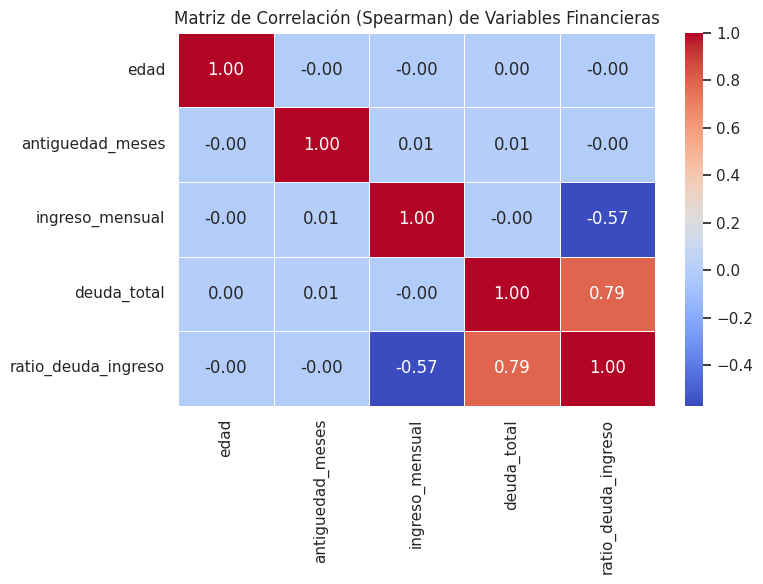

In [167]:
# --- MATRIZ DE CORRELACIÓN (SPEARMAN) ---
# Seleccionamos solo algunas numéricas clave para no hacer un gráfico gigante
vars_numericas = ['edad', 'antiguedad_meses', 'ingreso_mensual', 'deuda_total', 'ratio_deuda_ingreso']

plt.figure(figsize=(8, 6))
# Usamos method='spearman' porque tenemos outliers controlados y no todo es lineal
sns.heatmap(data_clean[vars_numericas].corr(method='spearman'),
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)
plt.title('Matriz de Correlación (Spearman) de Variables Financieras')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3159/809387164.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_clean, x='abandono', y='ratio_deuda_ingreso', palette='Set1', ax=axes[1])


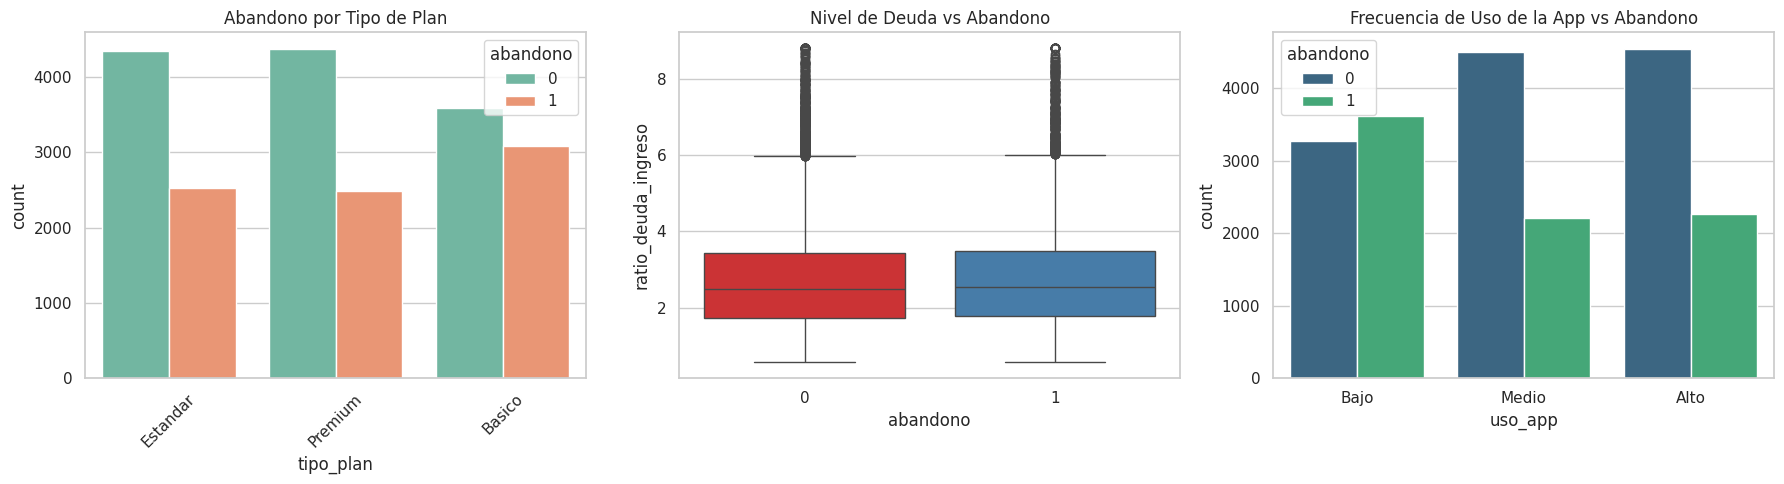

In [168]:
# --- GRÁFICOS PARA EL INFORME ---
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo de los gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1
sns.countplot(data=data_clean, x='tipo_plan', hue='abandono', palette='Set2', ax=axes[0])
axes[0].set_title('Abandono por Tipo de Plan')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2
sns.boxplot(data=data_clean, x='abandono', y='ratio_deuda_ingreso', palette='Set1', ax=axes[1])
axes[1].set_title('Nivel de Deuda vs Abandono')

# Gráfico 3
sns.countplot(data=data_clean, x='uso_app', hue='abandono', palette='viridis', ax=axes[2])
axes[2].set_title('Frecuencia de Uso de la App vs Abandono')

plt.tight_layout()
plt.show()